# One Dimensional Analysis applied to Sea Levels Without Using External Agents


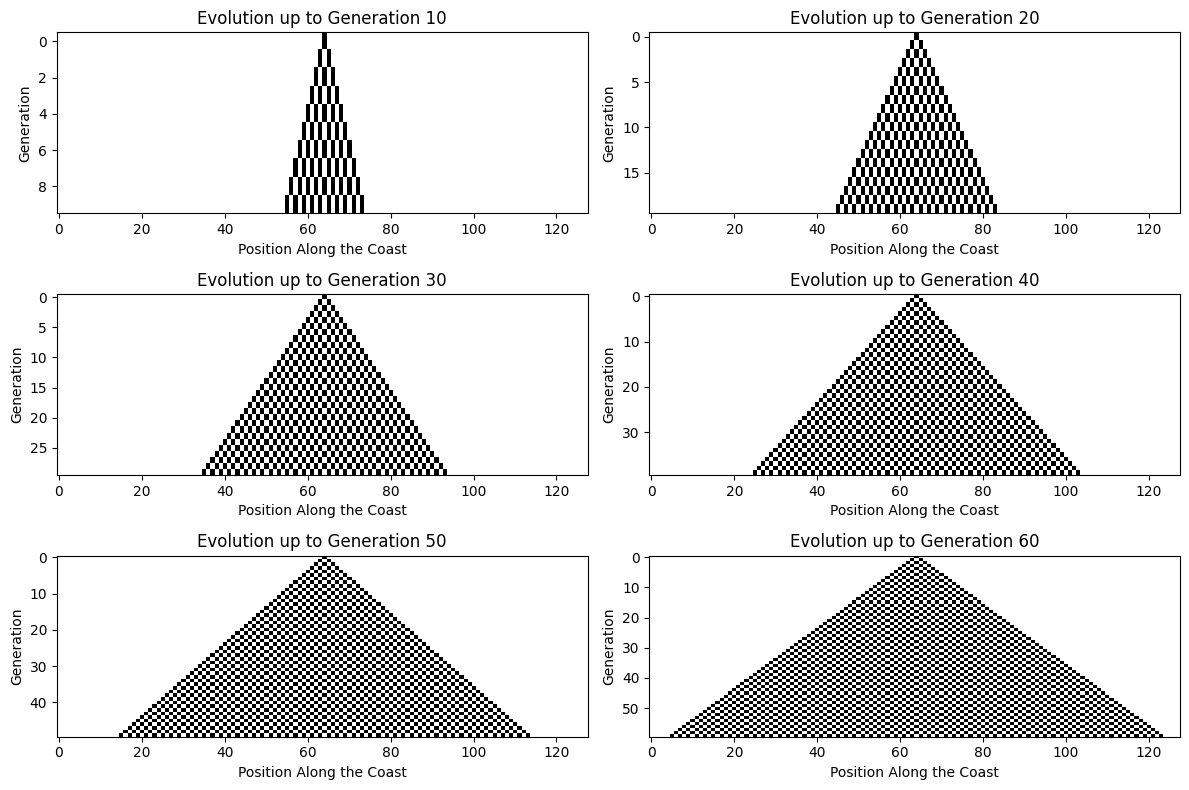

In [38]:
import numpy as np
import matplotlib.pyplot as plt

def rule_250(cells):
    new_configuration = np.zeros_like(cells)
    cells = cells.astype(int)

    for i in range(1, len(cells) - 1):
        neighborhood = (cells[i-1] << 2) | (cells[i] << 1) | cells[i+1]
        new_configuration[i] = (250 >> neighborhood) & 1

    return new_configuration

def simulate_automaton(initial_cells, num_generations):
    cells = initial_cells.copy().astype(int)
    evolutions = [cells.copy()]

    for _ in range(num_generations):
        cells = rule_250(cells)
        evolutions.append(cells.copy())

    return evolutions

n = 128
num_generations = 64
initial_cells = np.zeros(n, dtype=int)
initial_cells[n // 2] = 1

evolutions = simulate_automaton(initial_cells, num_generations)

evolutions = np.array(evolutions)

plt.figure(figsize=(12, 8))
for i in range(10, num_generations + 1, 10):
    plt.subplot(3, 2, i // 10)
    plt.imshow(evolutions[:i], cmap='binary', interpolation='nearest', aspect='auto')
    plt.title(f"Evolution up to Generation {i}")
    plt.xlabel("Position Along the Coast")
    plt.ylabel("Generation")

plt.tight_layout()
plt.show()


# One Dimensional Analysis applied to Sea Levels Using Generational Temperature Rise

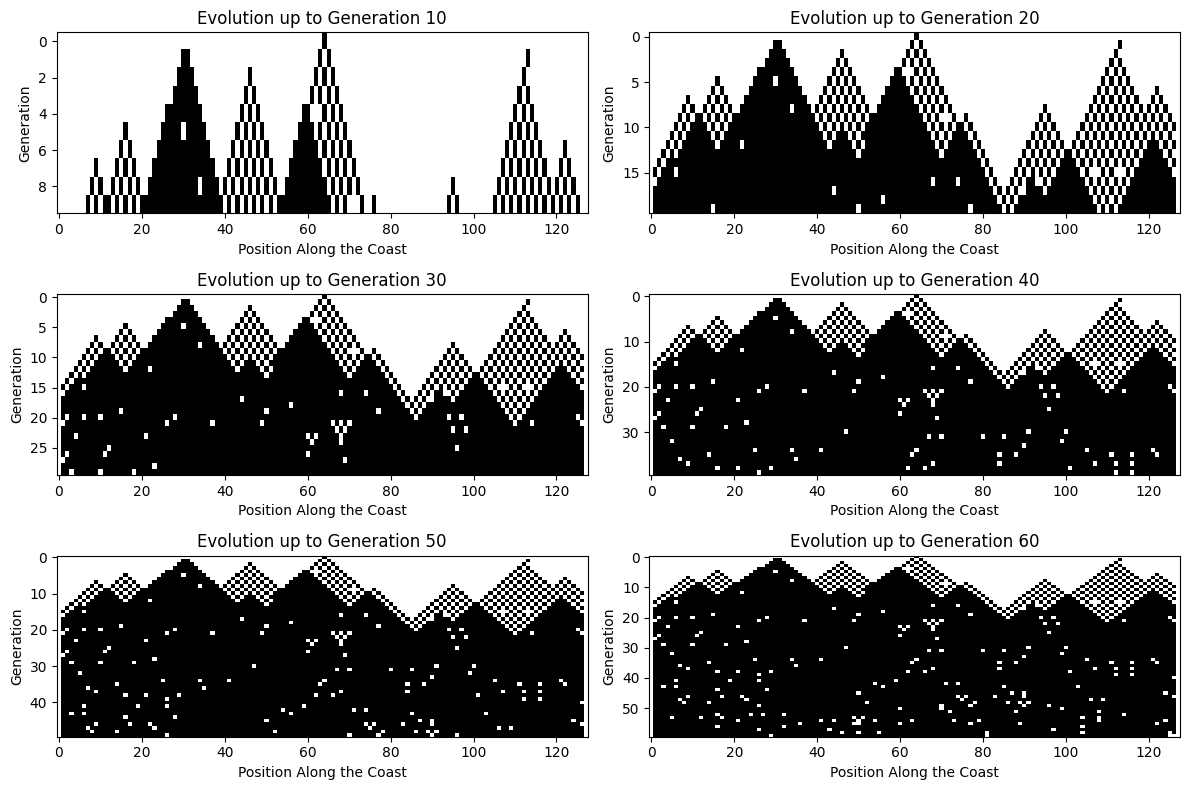

In [37]:
import numpy as np
import matplotlib.pyplot as plt

def rule_250_with_temperature(cells, temperature):
    new_configuration = np.zeros_like(cells)
    cells = cells.astype(int)
    for i in range(1, len(cells) - 1):
        neighborhood = (cells[i-1] << 2) | (cells[i] << 1) | cells[i+1]
        next_state = (250 >> neighborhood) & 1
        flip_chance = np.random.random()
        if flip_chance < (temperature / 100):
            next_state = 1 - next_state
        new_configuration[i] = next_state
    return new_configuration

def simulate_automaton_with_temperature(initial_cells, num_generations, initial_temperature, temperature_increment):
    cells = initial_cells.copy().astype(int)
    evolutions = [cells.copy()]
    temperature = initial_temperature
    for g in range(num_generations):
        cells = rule_250_with_temperature(cells, temperature)
        evolutions.append(cells.copy())
        temperature += temperature_increment
    return evolutions

n = 128  #number of cells
num_generations = 64  #number of generations
initial_cells = np.zeros(n, dtype=int)
initial_cells[n // 2] = 1
initial_temperature = 1
temperature_increment = 0.05  #temperature increment per generation

evolutions = simulate_automaton_with_temperature(initial_cells, num_generations, initial_temperature, temperature_increment)

evolutions = np.array(evolutions)
plt.figure(figsize=(12, 8))
for i in range(10, num_generations + 1, 10):
    plt.subplot(3, 2, i // 10)
    plt.imshow(evolutions[:i], cmap='binary', interpolation='nearest', aspect='auto')
    plt.title(f"Evolution up to Generation {i}")
    plt.xlabel("Position Along the Coast")
    plt.ylabel("Generation")

plt.tight_layout()
plt.show()
